
<font size = "5"> **Chapter 2: [Diffraction](../Diffraction/CH2_00-Diffraction.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />

# HW7:  Simulating CBED Pattern

[Download](https://raw.githubusercontent.com/gduscher/MSE672-Introduction-to-TEM//main/Homework/Homework08.ipynb)
 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
    https://colab.research.google.com/github/gduscher/MSE672-Introduction-to-TEM/blob/main/Homework/Homework08.ipynb)



part of 

<font size = "5"> **[MSE672:  Introduction to Transmission Electron Microscopy](../_MSE672_Intro_TEM.ipynb)**</font>

by Gerd Duscher, Spring 2026

Microscopy Facilities<br>
Institute of Advanced Materials & Manufacturing<br>
Materials Science & Engineering<br>
The University of Tennessee, Knoxville

Background and methods to analysis and quantification of data acquired with transmission electron microscopes


## Homework Assignment

Simulate a silicon [011] CBED diffraction pattern from Lab 5 (use the one with the higher camera length).

- We focus on the zero disk.
- Change the maximum thickness to match the zero disk between simulation and your chosen experimental CBED pattern.
- Show both in a document format of your choice.

>
>Please note that you will have to activate the ``GPU`` in ``Colab`` under the Menu ``Runtime`` select ``Change runtime type`` 
>

Questions:

1. Set the convergence angle to the value you derived at in Homework 5 (please note, here it has to be in mrad not 1/nm))
2. What thickness did you arrive at?
3. How can you change the intensity in the middle of the zero disk?
4. How is that related with the intensity in the center of the [220] disks?


## Load relevant python packages
### Check Installed Packages

In [4]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

# pyTEMlib setup ------------------
if test_package('pyTEMlib') < '0.2026.1.3':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install  --upgrade pyTEMlib -q
if test_package('abtem') < '1.0.0b17':
        print('installing abtem')
!{sys.executable} -m pip install  --upgrade abtem -q
# ------------------------------

print('done')

done


### Import numerical and plotting python packages
This notebook: only requires:
* matplotlib: for plotting
* numpy for numerical arrays
* ase: for the structure
* abtem: for the multislice calculation

In [1]:
%matplotlib widget
import matplotlib.pylab as plt
import numpy as np
# import atomic simulation environment
import ase
import ase.build
import ase.visualize

# import ab-initio-tem library
import abtem

If you have a GPU set the device below to GPU

In [2]:
abtem.config.set({"device": "cpu", "fft": "fftw"})

## Let's Make a Structure
>
> Here we make Si in the [011] direction 
>

Change the input here

Atoms(symbols='Si299904', pbc=True, cell=[46.075077862115435, 43.44, 2998.719650859346], tags=...)

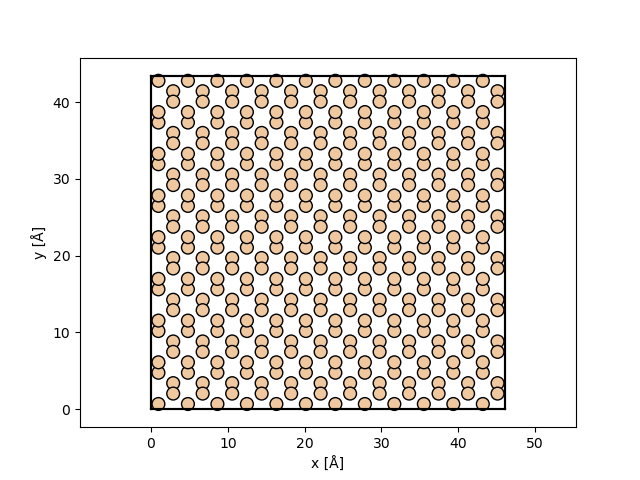

In [4]:
# ------------ Input ----------
thickness = 100. #  in nm
number_of_layers = 2  # per unit cell
zone_axis = [1, 1, 0]
#------------------------------


atoms = ase.build.bulk('Si', 'diamond', cubic=True)
silicon_110 = ase.build.surface(atoms, zone_axis, 1, vacuum=None, tol=1e-10, periodic=True)
lattice_parameter = silicon_110.cell[2,2]
layers = int(thickness / lattice_parameter *10) # lattice parameter is in Angstrom
silicon_110 *= (6, 8, layers)
silicon_110.center()
abtem.show_atoms(silicon_110)
silicon_110


### Make the potential

We are using the frozen phonon approximation to make a varied potential.

Sigma is the averge deviation of positions from the symmetric sites (in Angstrom). Please do not change that value.

Please note that I am using 1024 by 1024 pixels (set by the gpts variable)

In [5]:
frozen_phonons = abtem.FrozenPhonons(silicon_110, 8, {"Si": 0.078})

In [6]:
# ------ input ------
number_of_thicknes_outputs = 10
# -------------------
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,
    projection="infinite",
    slice_thickness=lattice_parameter/number_of_layers,
    exit_planes=int(silicon_110.cell[2,2]/number_of_thicknes_outputs),
)
potential.shape

(8, 1562, 461, 435)

This takes a while, you can skip it!

In [15]:
visualization = potential[:5].sum(axis=1).show(
    project=False,
    figsize=(14, 5),
    common_color_scale=True,
    cbar=True,
);
lattice_parameter

KeyboardInterrupt: 

##  Definition of electron probe

The probe profile gives us an estmate of the probed volume.

In [8]:
# -------- Input --------
convergence_angle = 3.5  # in mrad
acceleration_voltage = 200 * 1000.
device = 'cpu'
# -----------------------

probe = abtem.Probe(energy=acceleration_voltage, semiangle_cutoff=convergence_angle,  device=device)
probe.grid.match(potential)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

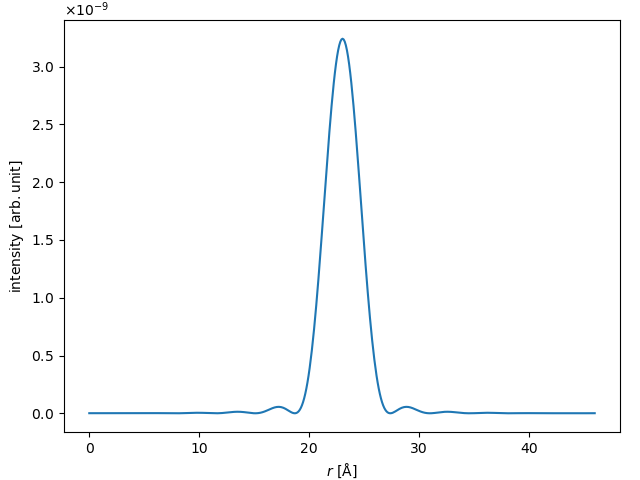

In [9]:
probe.profiles().show();

## Multislice calculation


In [13]:
measurement = probe.multislice(potential).diffraction_patterns(max_angle=50)

measurement = measurement.mean(0)
measurement.compute()


tasks:   0%|          | 0/34 [00:00<?, ?it/s]

## Output
I only plot the last 4 (-4, -3, -2, -1)  and the second (python always starts at 0) CBED pattern.

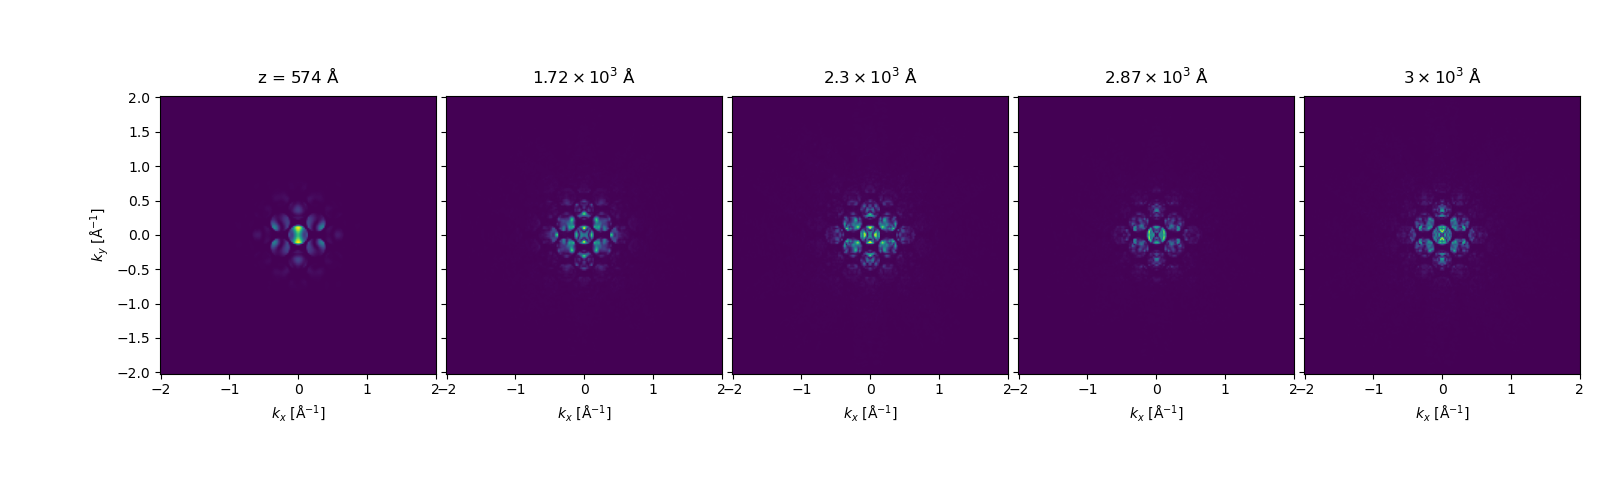

In [14]:
visualization = measurement.interpolate(0.004)[[1, -4, -3, -2, -1]].show(
    explode=True,
    figsize=(16, 5))
measurement

(7, 185, 175)

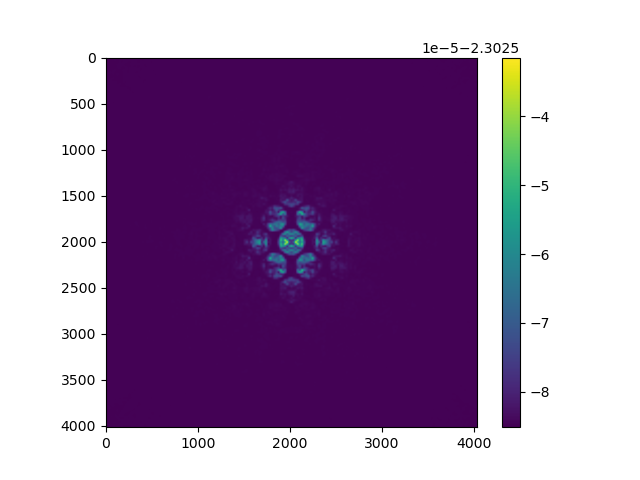

In [17]:
plt.figure()
plt.imshow(np.log(.1+measurement[-1].interpolate(0.001).array))
plt.colorbar()
measurement.shape

## Repeat 

Repeat with different thickness till you get the right pattern in the zero disk of the CBED pattern of homework 5 (return to the structure code cell)

## Save the calculation

We save the numpy array, you can download this file in google colab from the file menu on the left.

In [55]:
with open('Si011-slice0_1.npy', 'wb') as f:
    np.save(f, measurement.array[-1])